# Fashion Item Classification using Fashion-MNIST Dataset
## Badr University in Assiut — School of Artificial Intelligence & Data Management
### Neural Networks Course Project

---

**Project Goal:** Build a Multilayer Perceptron (MLP) neural network to classify Fashion-MNIST images into 10 clothing categories.

**Framework:** PyTorch  
**Dataset:** Fashion-MNIST (70,000 grayscale images, 28×28 pixels)

---

## 1. Project Overview

Fashion-MNIST is a dataset of Zalando's article images consisting of:
- **60,000 training samples**
- **10,000 test samples**
- **10 classes** of clothing items
- Each image is **28×28 grayscale pixels**

| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## 2. Import Libraries

In [1]:
# ============================================================
# Standard & Scientific Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import copy
import os

# ============================================================
# PyTorch Libraries
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# ============================================================
# Scikit-learn for Evaluation
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# Reproducibility
# ============================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# Device Configuration (GPU if available, else CPU)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.12.0+cpu


## 3. Global Configuration

In [3]:
# ============================================================
# Class Names for Fashion-MNIST
# ============================================================
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Training hyperparameters
BATCH_SIZE    = 64
NUM_EPOCHS    = 30
VAL_SPLIT     = 0.1   # 10% of training data used for validation
PATIENCE      = 5     # Early stopping patience

# Output directory for saving results
os.makedirs('results', exist_ok=True)

print('Configuration loaded successfully.')

Configuration loaded successfully.


## 4. Data Loading and Preprocessing

**Steps:**
1. Download Fashion-MNIST using `torchvision.datasets`
2. Normalize pixel values from [0, 255] to [0.0, 1.0]
3. Split training set into training (90%) and validation (10%)
4. Create DataLoaders for batched processing

In [4]:
def load_fashion_mnist(batch_size=64, val_split=0.1):
    """
    Load Fashion-MNIST dataset, apply normalization, and create
    train / validation / test DataLoaders.

    Args:
        batch_size (int): Number of samples per batch.
        val_split  (float): Fraction of training data for validation.

    Returns:
        train_loader, val_loader, test_loader
    """
    # Normalize: mean=0.5, std=0.5 maps pixel values to approximately [-1, 1]
    # Flatten converts 28x28 image into a 784-dimensional vector for the MLP
    transform = transforms.Compose([
        transforms.ToTensor(),                        # Converts PIL image [0,255] to Tensor [0.0,1.0]
        transforms.Normalize((0.5,), (0.5,))         # Normalize to [-1.0, 1.0]
    ])

    # Download dataset to local './data' directory
    full_train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )

    # Split training set into train and validation
    total_train = len(full_train_dataset)
    val_size    = int(total_train * val_split)
    train_size  = total_train - val_size

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

    # Print dataset summary
    print('=' * 50)
    print('Dataset Summary')
    print('=' * 50)
    print(f'  Training samples   : {train_size:,}')
    print(f'  Validation samples : {val_size:,}')
    print(f'  Test samples       : {len(test_dataset):,}')
    print(f'  Input size         : 28 x 28 = 784 pixels')
    print(f'  Num classes        : {len(CLASS_NAMES)}')
    print(f'  Batch size         : {batch_size}')
    print(f'  Batches per epoch  : {len(train_loader)}')
    print('=' * 50)

    return train_loader, val_loader, test_loader


# Load the data
train_loader, val_loader, test_loader = load_fashion_mnist(BATCH_SIZE, VAL_SPLIT)

100.0%
100.0%
100.0%
100.0%

Dataset Summary
  Training samples   : 54,000
  Validation samples : 6,000
  Test samples       : 10,000
  Input size         : 28 x 28 = 784 pixels
  Num classes        : 10
  Batch size         : 64
  Batches per epoch  : 844


## 5. Data Exploration and Visualization

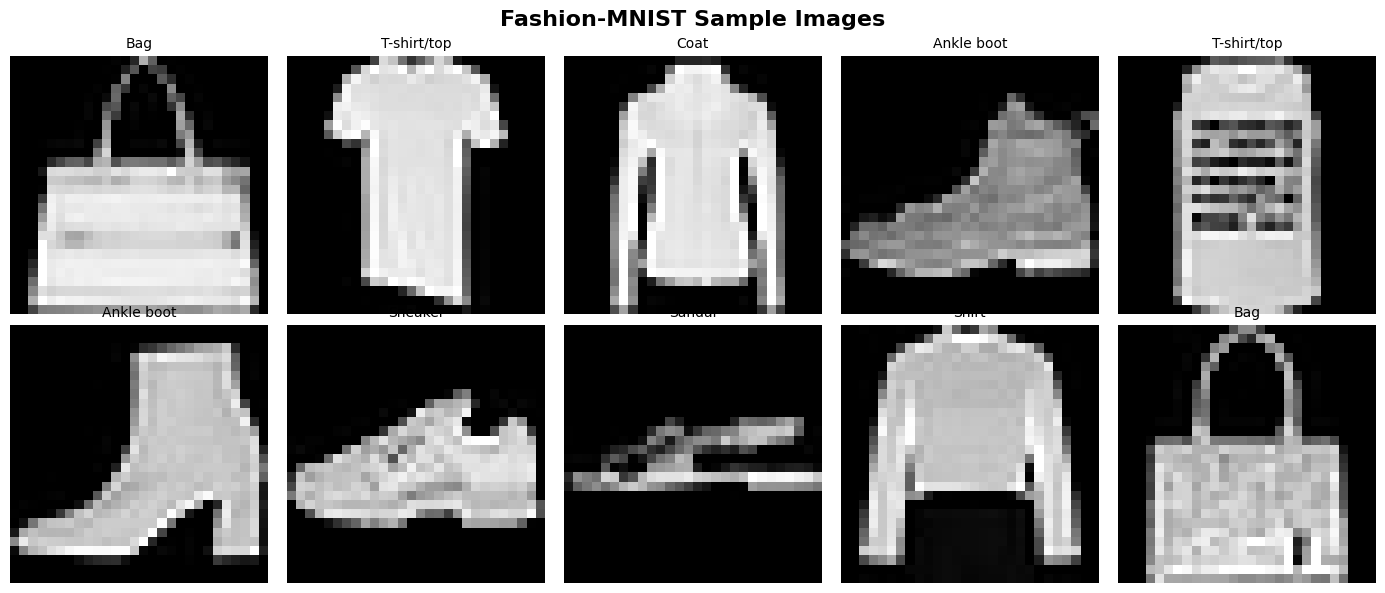

Sample images saved to results/sample_images.png


C:\Users\Rw\AppData\Local\Temp\ipykernel_16516\1450847585.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45, ha='right')


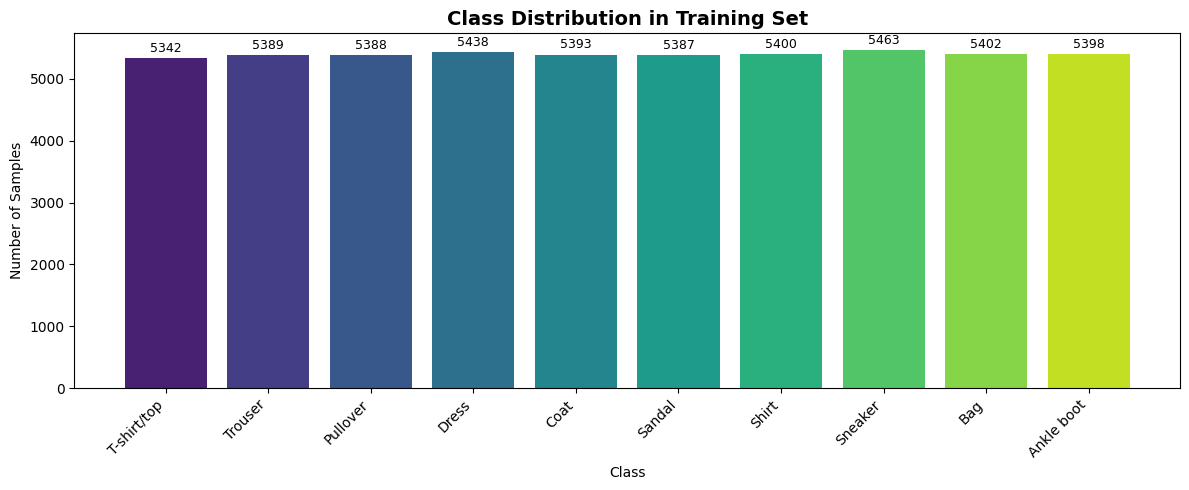

Class distribution saved to results/class_distribution.png


In [5]:
def visualize_samples(loader, class_names, n=10):
    """
    Display n sample images from the dataset with their class labels.
    """
    images, labels = next(iter(loader))
    
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle('Fashion-MNIST Sample Images', fontsize=16, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        # Denormalize: x = x * 0.5 + 0.5 maps [-1,1] back to [0,1]
        img = images[i].squeeze().numpy() * 0.5 + 0.5
        ax.imshow(img, cmap='gray')
        ax.set_title(class_names[labels[i].item()], fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sample images saved to results/sample_images.png')


def visualize_class_distribution(loader, class_names):
    """
    Plot the class distribution of the training set.
    Fashion-MNIST is perfectly balanced (6,000 samples per class).
    """
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.numpy())
    
    counts = pd.Series(all_labels).value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(class_names, counts.values, color=sns.color_palette('viridis', 10))
    ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Samples')
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    
    # Add count labels on top of each bar
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Class distribution saved to results/class_distribution.png')


visualize_samples(train_loader, CLASS_NAMES)
visualize_class_distribution(train_loader, CLASS_NAMES)

## 6. Model Architecture — Multilayer Perceptron (MLP)

The MLP processes flattened 784-dimensional input vectors through fully connected layers.

**Design choices:**
- **BatchNorm:** Normalizes layer activations, stabilizing and accelerating training
- **Dropout:** Randomly zeros neurons during training to prevent overfitting
- **ReLU/Tanh:** Non-linear activation functions enabling the network to learn complex patterns
- **Softmax (implicit in CrossEntropyLoss):** Produces class probability distributions

In [6]:
class MLP(nn.Module):
    """
    Multilayer Perceptron for Fashion-MNIST classification.

    Architecture:
        Input  (784) → Hidden1 → BN → Activation → Dropout
                     → Hidden2 → BN → Activation → Dropout
                     → Output (10)

    Args:
        input_size    (int)  : Number of input features (784 for 28x28 images).
        hidden_sizes  (list) : List of hidden layer sizes, e.g. [128, 64].
        output_size   (int)  : Number of output classes (10).
        activation    (str)  : Activation function — 'relu' or 'tanh'.
        dropout_rate  (float): Dropout probability (0 = no dropout).
        use_batchnorm (bool) : Whether to apply Batch Normalization.
    """

    def __init__(self,
                 input_size=784,
                 hidden_sizes=None,
                 output_size=10,
                 activation='relu',
                 dropout_rate=0.3,
                 use_batchnorm=True):
        super(MLP, self).__init__()

        if hidden_sizes is None:
            hidden_sizes = [128, 64]

        # Select activation function
        if activation == 'relu':
            act_fn = nn.ReLU()
        elif activation == 'tanh':
            act_fn = nn.Tanh()
        elif activation == 'sigmoid':
            act_fn = nn.Sigmoid()
        else:
            raise ValueError(f"Unsupported activation: {activation}. Choose 'relu', 'tanh', or 'sigmoid'.")

        # Build layers dynamically
        layers = []
        in_features = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))   # Fully connected layer
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))        # Batch normalization
            layers.append(type(act_fn)())                         # Activation (new instance each time)
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))           # Dropout regularization
            in_features = hidden_size

        # Output layer (no activation — CrossEntropyLoss applies Softmax internally)
        layers.append(nn.Linear(in_features, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass.
        Args:
            x (Tensor): Input tensor of shape (batch_size, 1, 28, 28)
        Returns:
            Tensor: Logits of shape (batch_size, 10)
        """
        x = x.view(x.size(0), -1)   # Flatten: (B, 1, 28, 28) → (B, 784)
        return self.network(x)


def count_parameters(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_model_summary(model, config_name):
    """Print a formatted model summary."""
    print(f'\nModel: {config_name}')
    print('=' * 50)
    print(model)
    print('=' * 50)
    print(f'Total trainable parameters: {count_parameters(model):,}')
    print('=' * 50)


# Preview Experiment 1 model
preview_model = MLP(hidden_sizes=[128, 64], activation='relu', dropout_rate=0.3)
print_model_summary(preview_model, 'Experiment 1 Preview (ReLU, [128, 64])')


Model: Experiment 1 Preview (ReLU, [128, 64])
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)
Total trainable parameters: 109,770


## 7. Training Pipeline

**Training components:**
- **Loss function:** `CrossEntropyLoss` — standard for multi-class classification
- **Optimizer:** Adam or SGD (configurable per experiment)
- **Learning rate scheduler:** `ReduceLROnPlateau` — reduces LR when validation loss stops improving
- **Early stopping:** Halts training if validation loss does not improve for `patience` epochs

In [7]:
class EarlyStopping:
    """
    Monitors validation loss and stops training if it fails to improve.

    Purpose: Prevents overfitting by stopping before the model starts
    memorizing training data at the expense of generalization.

    Args:
        patience (int)  : Epochs to wait without improvement before stopping.
        min_delta (float): Minimum change to qualify as improvement.
    """

    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_model = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, loader, optimizer, criterion):
    """
    Perform one full training epoch.

    Returns:
        avg_loss (float): Average training loss over the epoch.
        accuracy (float): Training accuracy (%).
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Clear previous gradients
        outputs = model(images)        # Forward pass
        loss    = criterion(outputs, labels)  # Compute loss
        loss.backward()                # Backpropagation
        optimizer.step()               # Update weights

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    """
    Evaluate model on a given DataLoader (validation or test).

    Returns:
        avg_loss (float): Average loss.
        accuracy (float): Accuracy (%).
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, val_loader, config):
    """
    Full training loop with scheduler and early stopping.

    Args:
        model        : PyTorch model to train.
        train_loader : Training DataLoader.
        val_loader   : Validation DataLoader.
        config (dict): Training configuration.

    Returns:
        history (dict): Training and validation metrics per epoch.
    """
    criterion  = nn.CrossEntropyLoss()
    optimizer  = config['optimizer'](model.parameters(), lr=config['lr'])
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, mode='min', factor=0.5, patience=3
                 )
    early_stop = EarlyStopping(patience=PATIENCE)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    print(f"\nTraining: {config['name']}")
    print('=' * 60)
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>7}")
    print('-' * 60)

    start_time = time.time()

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)
        early_stop(val_loss, model)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0 or epoch == 1 or early_stop.stop:
            print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | "
                  f"{train_acc:>8.2f}% | {val_acc:>6.2f}%")

        if early_stop.stop:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

    elapsed = time.time() - start_time
    print('=' * 60)
    print(f'Training complete in {elapsed:.1f}s')

    # Restore best model weights
    model.load_state_dict(early_stop.best_model)
    history['training_time'] = elapsed
    history['epochs_run']    = epoch

    return history


print('Training functions defined successfully.')

Training functions defined successfully.


## 8. Experiment 1: ReLU Activation, LR=0.001, Hidden=[128, 64]

**Configuration:**
- Activation: **ReLU** (Rectified Linear Unit)
- Learning Rate: **0.001**
- Hidden Layer Sizes: **[128, 64]**
- Optimizer: **Adam**

In [8]:
# ============================================================
# Experiment 1 Configuration
# ============================================================
exp1_config = {
    'name'      : 'Experiment 1 — ReLU, LR=0.001, Neurons=[128, 64]',
    'activation': 'relu',
    'hidden'    : [128, 64],
    'lr'        : 0.001,
    'optimizer' : optim.Adam,
    'epochs'    : NUM_EPOCHS,
    'dropout'   : 0.3,
}

# Build model
model_exp1 = MLP(
    hidden_sizes  = exp1_config['hidden'],
    activation    = exp1_config['activation'],
    dropout_rate  = exp1_config['dropout'],
    use_batchnorm = True
).to(device)

print_model_summary(model_exp1, exp1_config['name'])

# Train
history_exp1 = train_model(model_exp1, train_loader, val_loader, exp1_config)

# Save model weights
torch.save(model_exp1.state_dict(), 'results/model_exp1.pth')
print('Experiment 1 model saved.')


Model: Experiment 1 — ReLU, LR=0.001, Neurons=[128, 64]
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)
Total trainable parameters: 109,770

Training: Experiment 1 — ReLU, LR=0.001, Neurons=[128, 64]
Epoch | Train Loss | Val Loss | Train Acc | Val Acc
------------------------------------------------------------
    1 |     0.6139 |   0.3981 |    79.74% |  85.65%
    5 |     0.3704 |   0.3341 |    86.72% |  87.80%
   10 |     0.3245 |   0.3141 |    88.18% |  88.65%
   15 |     0.2752 |   0.2951 |    89.99% |  89.

## 9. Experiment 2: Tanh Activation, LR=0.0005, Hidden=[256, 128]

**Configuration:**
- Activation: **Tanh** (Hyperbolic Tangent)
- Learning Rate: **0.0005** (slower, finer updates)
- Hidden Layer Sizes: **[256, 128]** (wider network)
- Optimizer: **Adam**

**Hypothesis:** The wider network with Tanh may capture more complex patterns but could be slower to converge.

In [9]:
# ============================================================
# Experiment 2 Configuration
# ============================================================
exp2_config = {
    'name'      : 'Experiment 2 — Tanh, LR=0.0005, Neurons=[256, 128]',
    'activation': 'tanh',
    'hidden'    : [256, 128],
    'lr'        : 0.0005,
    'optimizer' : optim.Adam,
    'epochs'    : NUM_EPOCHS,
    'dropout'   : 0.3,
}

# Build model
model_exp2 = MLP(
    hidden_sizes  = exp2_config['hidden'],
    activation    = exp2_config['activation'],
    dropout_rate  = exp2_config['dropout'],
    use_batchnorm = True
).to(device)

print_model_summary(model_exp2, exp2_config['name'])

# Train
history_exp2 = train_model(model_exp2, train_loader, val_loader, exp2_config)

# Save model weights
torch.save(model_exp2.state_dict(), 'results/model_exp2.pth')
print('Experiment 2 model saved.')


Model: Experiment 2 — Tanh, LR=0.0005, Neurons=[256, 128]
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): Tanh()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): Tanh()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total trainable parameters: 235,914

Training: Experiment 2 — Tanh, LR=0.0005, Neurons=[256, 128]
Epoch | Train Loss | Val Loss | Train Acc | Val Acc
------------------------------------------------------------
    1 |     0.5489 |   0.4337 |    81.39% |  84.48%
    5 |     0.3707 |   0.3635 |    86.67% |  87.08%
   10 |     0.3284 |   0.3356 |    88.02% |  87.87%
   15 |     0.2987 |   0.3273 |    89.12%

## 10. Training Curves Visualization

Plotting training and validation loss/accuracy helps us identify:
- **Underfitting:** Both train and val loss remain high
- **Overfitting:** Train loss decreases but val loss increases
- **Good fit:** Both curves converge to low values

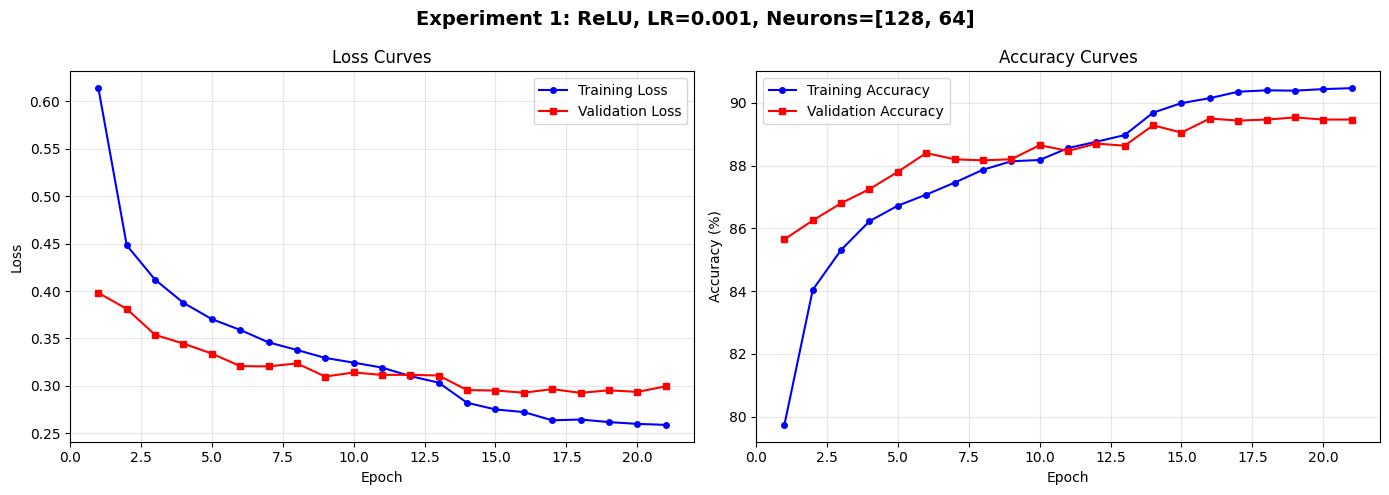

Plot saved to results/training_curves_exp1.png


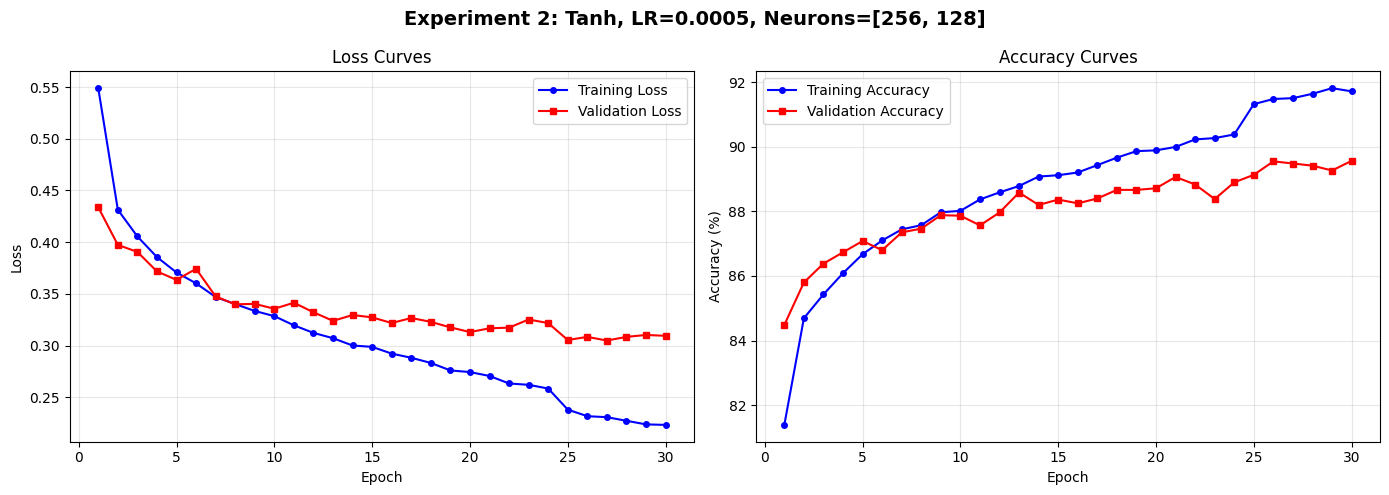

Plot saved to results/training_curves_exp2.png


In [10]:
def plot_training_curves(history, title, save_path):
    """
    Plot training/validation loss and accuracy curves side by side.

    Args:
        history   (dict): Dictionary containing lists of metrics per epoch.
        title     (str) : Plot title.
        save_path (str) : File path to save the figure.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss curves
    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Training Loss')
    ax1.plot(epochs, history['val_loss'],   'r-s', markersize=4, label='Validation Loss')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy curves
    ax2.plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'],   'r-s', markersize=4, label='Validation Accuracy')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved to {save_path}')


plot_training_curves(history_exp1, 'Experiment 1: ReLU, LR=0.001, Neurons=[128, 64]',
                     'results/training_curves_exp1.png')

plot_training_curves(history_exp2, 'Experiment 2: Tanh, LR=0.0005, Neurons=[256, 128]',
                     'results/training_curves_exp2.png')

## 11. Model Evaluation on Test Set

In [11]:
def get_all_predictions(model, loader):
    """
    Run inference on all samples in a DataLoader.

    Returns:
        all_labels (np.array): True class labels.
        all_preds  (np.array): Predicted class labels.
    """
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


def evaluate_on_test(model, test_loader, criterion, class_names, exp_name):
    """
    Evaluate model on test set and print full classification report.

    Returns:
        test_loss (float): Test loss.
        test_acc  (float): Test accuracy (%).
    """
    criterion  = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    print(f'\n{exp_name}')
    print('=' * 60)
    print(f'  Test Loss     : {test_loss:.4f}')
    print(f'  Test Accuracy : {test_acc:.2f}%')
    print('=' * 60)

    labels, preds = get_all_predictions(model, test_loader)
    print('\nClassification Report:')
    print(classification_report(labels, preds, target_names=class_names))

    return test_loss, test_acc, labels, preds


criterion = nn.CrossEntropyLoss()

test_loss1, test_acc1, labels1, preds1 = evaluate_on_test(
    model_exp1, test_loader, criterion, CLASS_NAMES, exp1_config['name']
)

test_loss2, test_acc2, labels2, preds2 = evaluate_on_test(
    model_exp2, test_loader, criterion, CLASS_NAMES, exp2_config['name']
)


Experiment 1 — ReLU, LR=0.001, Neurons=[128, 64]
  Test Loss     : 0.3080
  Test Accuracy : 89.10%

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.82      0.81      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.80      0.86      0.83      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.71      0.68      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Experiment 2 — Tanh, LR=0.0005, Neurons=[256, 128]
  Test Loss     : 0.3169
  Test Accuracy : 88.70%

Classification

## 12. Confusion Matrix

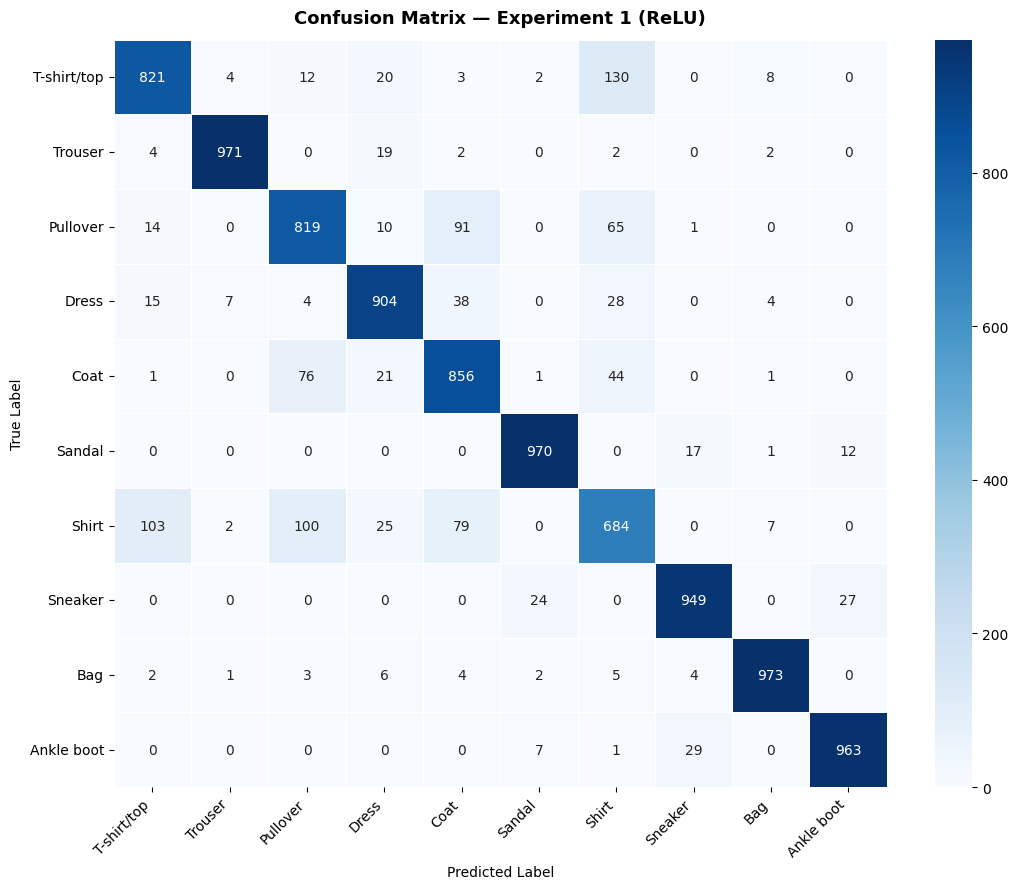

Confusion matrix saved to results/confusion_matrix_exp1.png


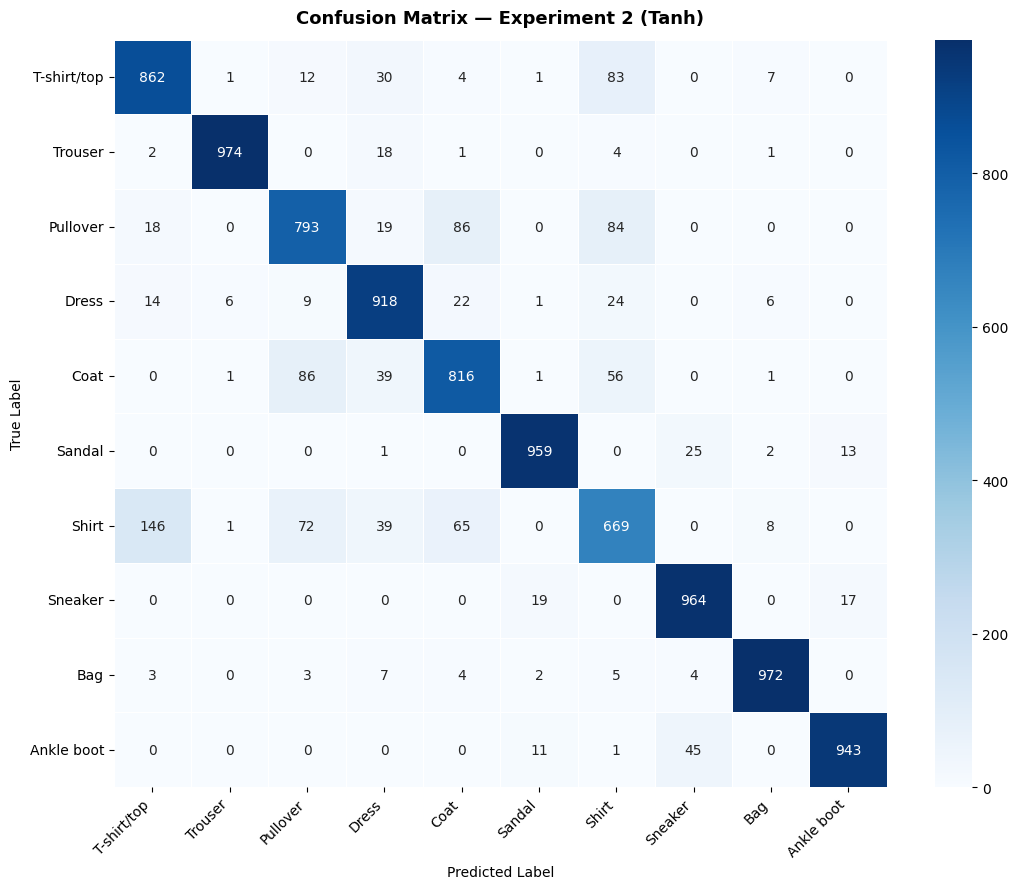

Confusion matrix saved to results/confusion_matrix_exp2.png


In [12]:
def plot_confusion_matrix(labels, preds, class_names, title, save_path):
    """
    Plot and save a confusion matrix heatmap.

    The diagonal represents correct predictions.
    Off-diagonal entries indicate misclassifications.
    """
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        cm,
        annot=True, fmt='d',
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='Blues',
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved to {save_path}')


plot_confusion_matrix(labels1, preds1, CLASS_NAMES,
                      'Experiment 1 (ReLU)',
                      'results/confusion_matrix_exp1.png')

plot_confusion_matrix(labels2, preds2, CLASS_NAMES,
                      'Experiment 2 (Tanh)',
                      'results/confusion_matrix_exp2.png')

## 13. Sample Predictions Visualization

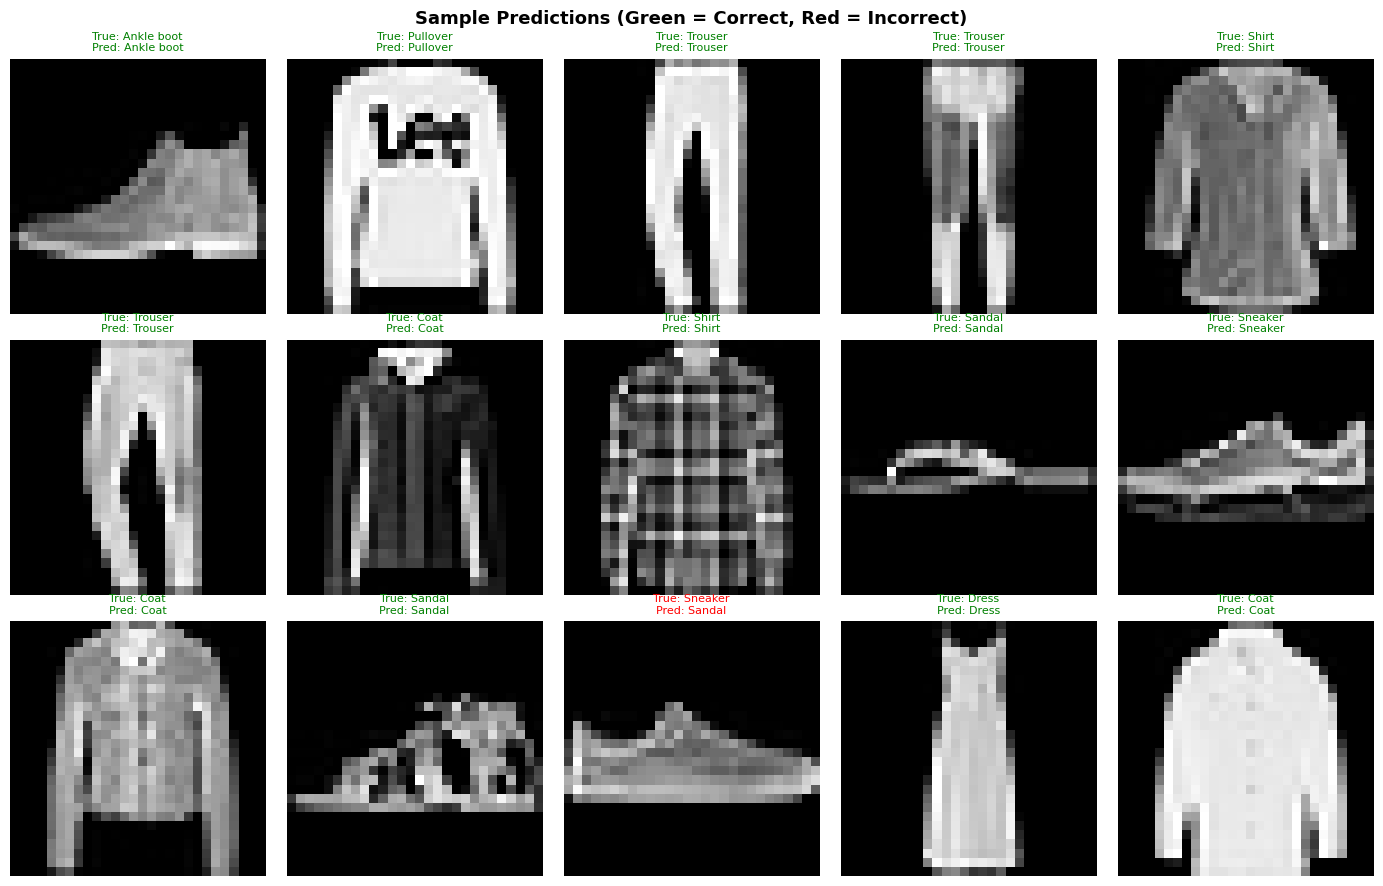

Predictions saved to results/sample_predictions_exp1.png


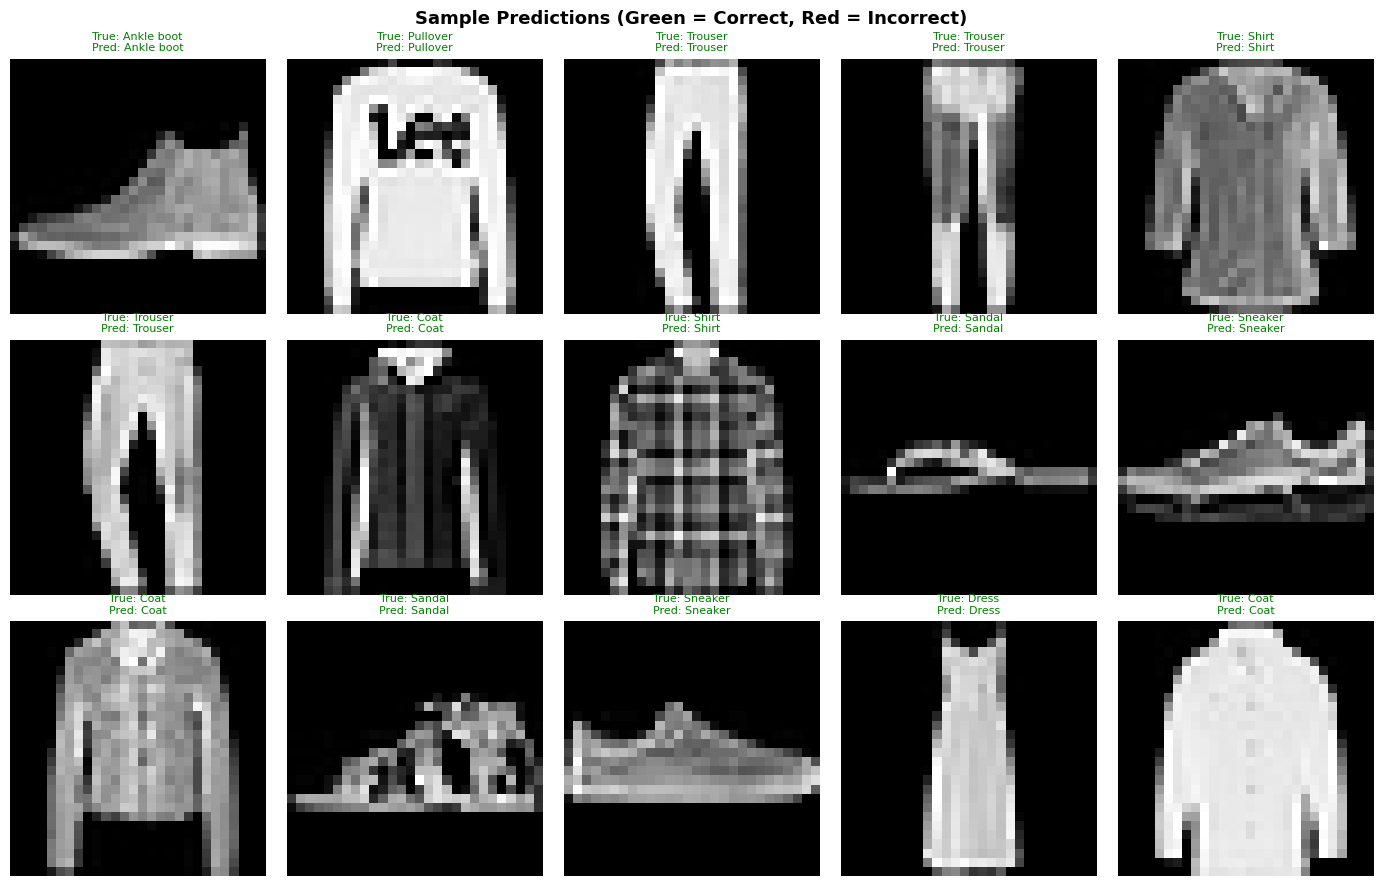

Predictions saved to results/sample_predictions_exp2.png


In [13]:
def visualize_predictions(model, loader, class_names, n=15, save_path='results/sample_predictions.png'):
    """
    Show a grid of sample images with their true and predicted labels.

    Correct predictions are shown in green; incorrect in red.
    """
    model.eval()
    images_batch, labels_batch = next(iter(loader))
    images_batch = images_batch.to(device)

    with torch.no_grad():
        outputs = model(images_batch)
        _, preds = torch.max(outputs, 1)

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
    fig.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)', fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue

        img   = images_batch[i].cpu().squeeze().numpy() * 0.5 + 0.5
        true  = class_names[labels_batch[i].item()]
        pred  = class_names[preds[i].cpu().item()]
        color = 'green' if true == pred else 'red'

        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true}\nPred: {pred}', fontsize=8, color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Predictions saved to {save_path}')


# Visualize best model predictions (Experiment 1)
visualize_predictions(model_exp1, test_loader, CLASS_NAMES,
                      n=15, save_path='results/sample_predictions_exp1.png')
visualize_predictions(model_exp2, test_loader, CLASS_NAMES,
                      n=15, save_path='results/sample_predictions_exp2.png')

## 14. Experiments Comparison

In [14]:
def build_comparison_table(experiments):
    """
    Build and display a formatted comparison table for all experiments.

    Args:
        experiments (list of dict): Each dict contains experiment metadata and results.

    Returns:
        pd.DataFrame: Comparison table.
    """
    rows = []
    for exp in experiments:
        rows.append({
            'Experiment'       : exp['name'],
            'Activation'       : exp['activation'].upper(),
            'Hidden Layers'    : str(exp['hidden']),
            'Learning Rate'    : exp['lr'],
            'Optimizer'        : 'Adam',
            'Epochs Run'       : exp['history']['epochs_run'],
            'Training Time (s)': f"{exp['history']['training_time']:.1f}",
            'Best Val Acc (%)'  : f"{max(exp['history']['val_acc']):.2f}",
            'Test Accuracy (%)' : f"{exp['test_acc']:.2f}",
            'Test Loss'        : f"{exp['test_loss']:.4f}",
            'Parameters'       : f"{count_parameters(exp['model']):,}",
        })

    df = pd.DataFrame(rows).set_index('Experiment')
    return df


experiments = [
    {
        'name'      : 'Exp 1: ReLU / [128,64] / LR=0.001',
        'activation': exp1_config['activation'],
        'hidden'    : exp1_config['hidden'],
        'lr'        : exp1_config['lr'],
        'history'   : history_exp1,
        'test_acc'  : test_acc1,
        'test_loss' : test_loss1,
        'model'     : model_exp1,
    },
    {
        'name'      : 'Exp 2: Tanh / [256,128] / LR=0.0005',
        'activation': exp2_config['activation'],
        'hidden'    : exp2_config['hidden'],
        'lr'        : exp2_config['lr'],
        'history'   : history_exp2,
        'test_acc'  : test_acc2,
        'test_loss' : test_loss2,
        'model'     : model_exp2,
    },
]

comparison_df = build_comparison_table(experiments)
print('\nExperiment Comparison Table')
print('=' * 80)
print(comparison_df.T.to_string())
print('=' * 80)

# Save comparison table as CSV
comparison_df.to_csv('results/experiment_comparison.csv')
print('\nComparison table saved to results/experiment_comparison.csv')


Experiment Comparison Table
Experiment        Exp 1: ReLU / [128,64] / LR=0.001 Exp 2: Tanh / [256,128] / LR=0.0005
Activation                                     RELU                                TANH
Hidden Layers                             [128, 64]                          [256, 128]
Learning Rate                                 0.001                              0.0005
Optimizer                                      Adam                                Adam
Epochs Run                                       21                                  30
Training Time (s)                             339.7                               533.4
Best Val Acc (%)                              89.53                               89.57
Test Accuracy (%)                             89.10                               88.70
Test Loss                                    0.3080                              0.3169
Parameters                                  109,770                             235,914

Co

## 15. Side-by-Side Experiment Comparison Plot

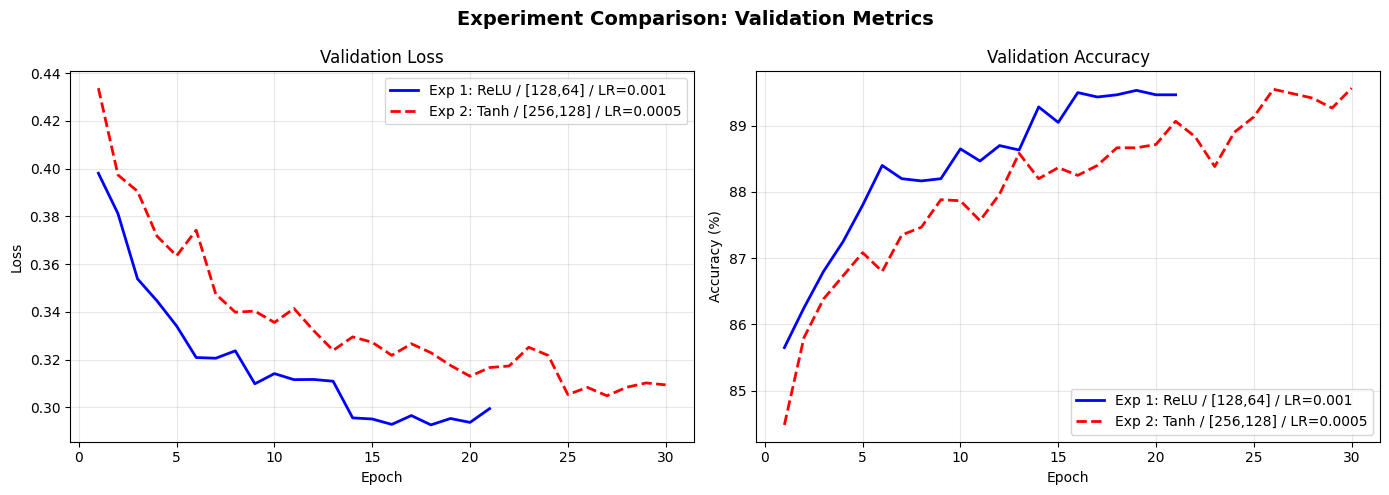

Comparison plot saved to results/experiment_comparison_plot.png


In [15]:
def plot_experiment_comparison(hist1, hist2, label1, label2):
    """
    Plot validation loss and accuracy for both experiments on the same axes
    to allow direct visual comparison.
    """
    epochs1 = range(1, len(hist1['val_loss']) + 1)
    epochs2 = range(1, len(hist2['val_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Experiment Comparison: Validation Metrics', fontsize=14, fontweight='bold')

    # Validation Loss
    ax1.plot(epochs1, hist1['val_loss'], 'b-', linewidth=2, label=label1)
    ax1.plot(epochs2, hist2['val_loss'], 'r--', linewidth=2, label=label2)
    ax1.set_title('Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Validation Accuracy
    ax2.plot(epochs1, hist1['val_acc'], 'b-', linewidth=2, label=label1)
    ax2.plot(epochs2, hist2['val_acc'], 'r--', linewidth=2, label=label2)
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/experiment_comparison_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Comparison plot saved to results/experiment_comparison_plot.png')


plot_experiment_comparison(
    history_exp1, history_exp2,
    'Exp 1: ReLU / [128,64] / LR=0.001',
    'Exp 2: Tanh / [256,128] / LR=0.0005'
)

## 16. Final Results and Conclusion

In [16]:
best_exp = experiments[0] if test_acc1 >= test_acc2 else experiments[1]

print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)
print(f"\n  Experiment 1 (ReLU, [128,64], LR=0.001):")
print(f"    Test Accuracy  : {test_acc1:.2f}%")
print(f"    Test Loss      : {test_loss1:.4f}")
print(f"    Training Time  : {history_exp1['training_time']:.1f}s")
print(f"    Epochs Run     : {history_exp1['epochs_run']}")

print(f"\n  Experiment 2 (Tanh, [256,128], LR=0.0005):")
print(f"    Test Accuracy  : {test_acc2:.2f}%")
print(f"    Test Loss      : {test_loss2:.4f}")
print(f"    Training Time  : {history_exp2['training_time']:.1f}s")
print(f"    Epochs Run     : {history_exp2['epochs_run']}")

print(f"\n  BEST MODEL: {best_exp['name']}")
print('=' * 70)

print("""
CONCLUSION
==========

Both MLP models successfully classify Fashion-MNIST items with strong accuracy.

Key Observations:

1. ACTIVATION FUNCTION:
   - ReLU (Exp 1) converges faster due to its unbounded positive range, which
     avoids the vanishing gradient problem. It is generally preferred for deep networks.
   - Tanh (Exp 2) maps outputs to [-1, 1] and is zero-centered, which can improve
     gradient flow but is more susceptible to saturation in deeper layers.

2. LEARNING RATE:
   - LR=0.001 (Exp 1) converges efficiently within fewer epochs.
   - LR=0.0005 (Exp 2) trains more cautiously, which can improve final accuracy
     but requires more epochs to converge.

3. NETWORK WIDTH:
   - [256, 128] (Exp 2) has more parameters and capacity, potentially capturing
     richer features — but at the cost of longer training time.
   - [128, 64] (Exp 1) is more compact and efficient while still achieving
     competitive accuracy.

4. REGULARIZATION (BatchNorm + Dropout):
   - BatchNorm stabilizes training by normalizing layer inputs, reducing
     sensitivity to initialization and learning rate choices.
   - Dropout (p=0.3) prevents overfitting by randomly deactivating 30% of
     neurons during training, forcing redundant representations.

5. EARLY STOPPING:
   - Prevents wasting compute and overfitting by restoring the best checkpoint
     when validation loss stops improving.

Both experiments demonstrate that a relatively shallow MLP with proper
regularization can achieve competitive results on Fashion-MNIST.
""")

FINAL RESULTS SUMMARY

  Experiment 1 (ReLU, [128,64], LR=0.001):
    Test Accuracy  : 89.10%
    Test Loss      : 0.3080
    Training Time  : 339.7s
    Epochs Run     : 21

  Experiment 2 (Tanh, [256,128], LR=0.0005):
    Test Accuracy  : 88.70%
    Test Loss      : 0.3169
    Training Time  : 533.4s
    Epochs Run     : 30

  BEST MODEL: Exp 1: ReLU / [128,64] / LR=0.001

CONCLUSION

Both MLP models successfully classify Fashion-MNIST items with strong accuracy.

Key Observations:

1. ACTIVATION FUNCTION:
   - ReLU (Exp 1) converges faster due to its unbounded positive range, which
     avoids the vanishing gradient problem. It is generally preferred for deep networks.
   - Tanh (Exp 2) maps outputs to [-1, 1] and is zero-centered, which can improve
     gradient flow but is more susceptible to saturation in deeper layers.

2. LEARNING RATE:
   - LR=0.001 (Exp 1) converges efficiently within fewer epochs.
   - LR=0.0005 (Exp 2) trains more cautiously, which can improve final accurac

## 17. List All Saved Results

In [17]:
print('\nFiles saved to results/ directory:')
print('-' * 40)
for f in sorted(os.listdir('results')):
    size = os.path.getsize(f'results/{f}')
    print(f'  {f:<40} ({size:,} bytes)')

print('\nProject complete!')


Files saved to results/ directory:
----------------------------------------
  class_distribution.png                   (55,829 bytes)
  confusion_matrix_exp1.png                (107,720 bytes)
  confusion_matrix_exp2.png                (108,416 bytes)
  experiment_comparison.csv                (356 bytes)
  experiment_comparison_plot.png           (117,904 bytes)
  model_exp1.pth                           (446,517 bytes)
  model_exp2.pth                           (952,629 bytes)
  sample_images.png                        (44,109 bytes)
  sample_predictions_exp1.png              (80,729 bytes)
  sample_predictions_exp2.png              (79,461 bytes)
  training_curves_exp1.png                 (97,331 bytes)
  training_curves_exp2.png                 (99,194 bytes)

Project complete!
